**Installing the necessary packages**

In [ ]:
install.packages("ggplot2")
install.packages("dplyr")
install.packages("tidyr")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



**Using the libraries (ggplot2, dplyr & tidyr)**

In [ ]:
library(ggplot2)
library(dplyr)
library(tidyr)

**Loading the dataset**

In [ ]:
orders     <- read.csv("/content/northstar-analytics/north_dataset/orders.csv",     stringsAsFactors = FALSE)
deliveries <- read.csv("/content/northstar-analytics/north_dataset/deliveries.csv", stringsAsFactors = FALSE)
complaints <- read.csv("/content/northstar-analytics/north_dataset/complaints.csv", stringsAsFactors = FALSE)
customers  <- read.csv("/content/northstar-analytics/north_dataset/customers.csv",  stringsAsFactors = FALSE)
drivers    <- read.csv("/content/northstar-analytics/north_dataset/drivers.csv",    stringsAsFactors = FALSE)
vehicles   <- read.csv("/content/northstar-analytics/north_dataset/vehicles.csv",   stringsAsFactors = FALSE)
incidents  <- read.csv("/content/northstar-analytics/north_dataset/incidents.csv",  stringsAsFactors = FALSE)
hubs       <- read.csv("/content/northstar-analytics/north_dataset/hubs.csv",       stringsAsFactors = FALSE)

**Cleaning the zone names**

In [ ]:
clean_zone <- function(x) {
  x <- tolower(trimws(x))
  x <- gsub("^airport$",          "Airport",   x)
  x <- gsub("^north$",            "North",     x)
  x <- gsub("^south$",            "South",     x)
  x <- gsub("^east$",             "East",      x)
  x <- gsub("^west$",             "West",      x)
  x <- gsub("^central$|^ctr$",    "Central",   x)
  x <- gsub("^riverside$",        "Riverside", x)
  return(x)
}

In [ ]:
orders$pickup_zone    <- clean_zone(orders$pickup_zone)
orders$dropoff_zone   <- clean_zone(orders$dropoff_zone)
drivers$base_zone     <- clean_zone(drivers$base_zone)
customers$home_zone   <- clean_zone(customers$home_zone)
vehicles$assigned_zone <- clean_zone(vehicles$assigned_zone)

cat("Zones are all cleaned\n")

Zones are all cleaned


**1st Analysis: Summary Statistics for Key Numeric Columns**

Before any visualisation, we look at the basic statistical summary of the most important numeric fields to understand the shape and the spread of data.

In [ ]:
cat("\n Summary: Order Values \n")
summary(orders$order_value)

cat("\n Summary: Customer Ratings \n")
summary(deliveries$customer_rating_post_delivery)

cat("\n Summary: Driver Ratings \n")
summary(drivers$driver_rating)

cat("\n Summary: Compensation Amounts \n")
summary(complaints$compensation_amount)

cat("\n Summary: Route Distance (km) \n")
summary(deliveries$route_distance_km)


 Summary: Order Values 


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   2.04   47.91   76.53   91.05  121.10  510.06 


 Summary: Customer Ratings 


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
  1.000   3.360   4.040   3.865   4.550   5.000      14 


 Summary: Driver Ratings 


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  3.150   3.905   4.175   4.172   4.478   5.000 


 Summary: Compensation Amounts 


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
  0.000   8.822  18.405  20.257  29.145  61.850      16 


 Summary: Route Distance (km) 


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.200   9.135  12.840  13.909  16.835  41.940 

**2nd Analysis: Delivery Status Distribution**

A simple count of how many deliveries were On Time, Delayed, or Failed across the entire operation.

In [ ]:
status_counts <- deliveries %>%
  group_by(delivery_status) %>%
  summarise(count = n())

cat("\n Delivery Status Counts \n")
print(status_counts)


 Delivery Status Counts 
# A tibble: 3 × 2
  delivery_status count
  <chr>           <int>
1 Delayed           202
2 Failed            132
3 OnTime            616


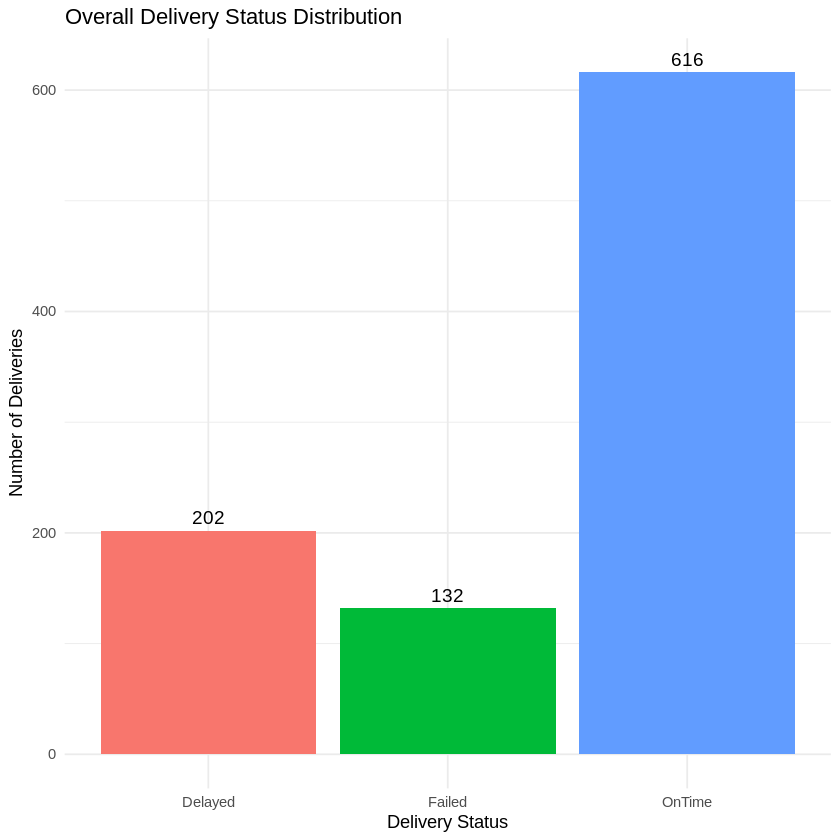

In [ ]:
ggplot(status_counts, aes(x = delivery_status, y = count, fill = delivery_status)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = count), vjust = -0.5, size = 4) +
  labs(
    title = "Overall Delivery Status Distribution",
    x     = "Delivery Status",
    y     = "Number of Deliveries"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

**3rd ANALYSIS: Order Value Distribution by Service Type**

A boxplot shows us the spread of order values for each service type, revealing which services are more lucrative and which have more variability in pricing.

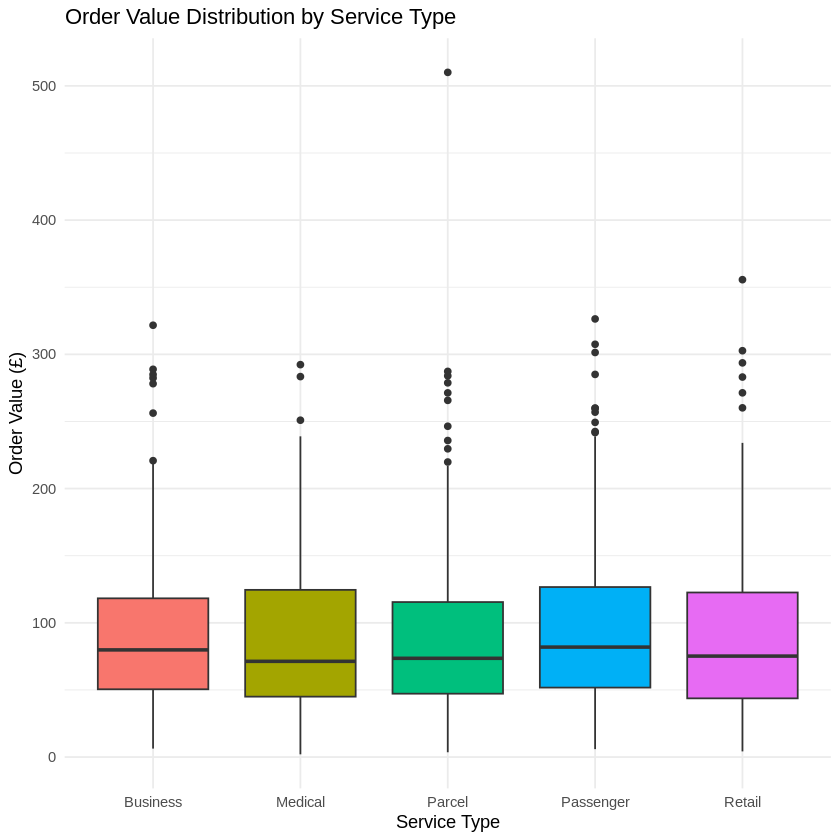

In [ ]:
ggplot(orders, aes(x = service_type, y = order_value, fill = service_type)) +
  geom_boxplot() +
  labs(
    title = "Order Value Distribution by Service Type",
    x     = "Service Type",
    y     = "Order Value (£)"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

**4th Analysis: Customer Rating Distribution**

A histogram shows how customer ratings are spread. A skew towards low ratings would indicate widespread dissatisfaction across the operation.

In [ ]:
# Remove the missing ratings first

ratings_clean <- deliveries %>%
  filter(!is.na(customer_rating_post_delivery))

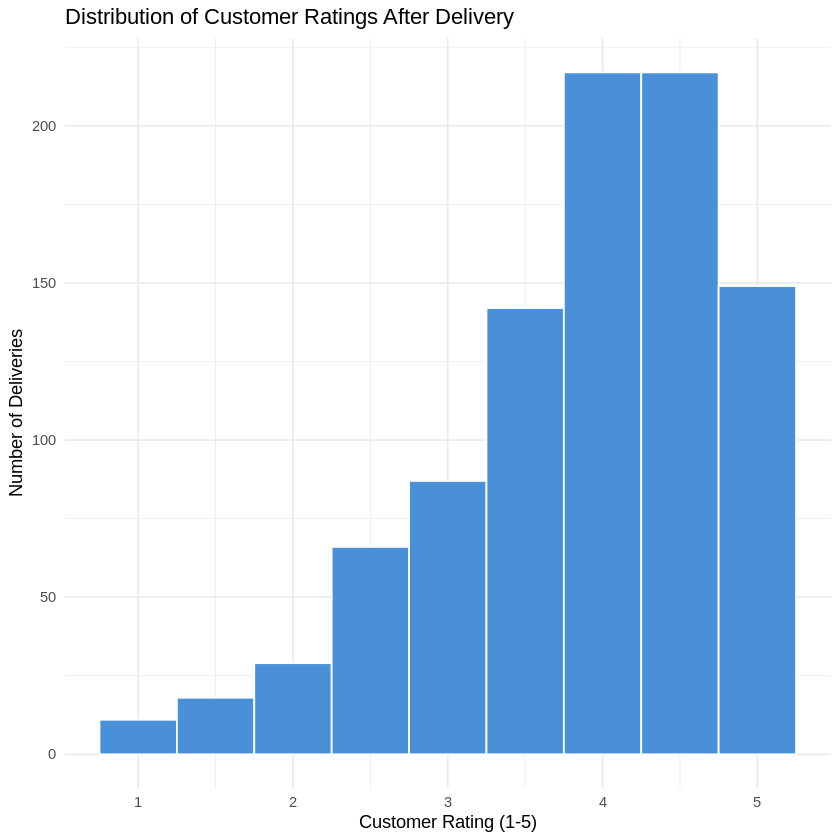

In [ ]:
ggplot(ratings_clean, aes(x = customer_rating_post_delivery)) +
  geom_histogram(binwidth = 0.5, fill = "#4a90d9", color = "white") +
  labs(
    title = "Distribution of Customer Ratings After Delivery",
    x     = "Customer Rating (1-5)",
    y     = "Number of Deliveries"
  ) +
  theme_minimal()

**5th Analysis: Correlation Between Driver Training and Rating **

We want to see if better trained drivers actually receive higher customer ratings. This can justify training investment.

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 7 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 7 rows containing missing values or values outside the scale range
(`geom_point()`).”


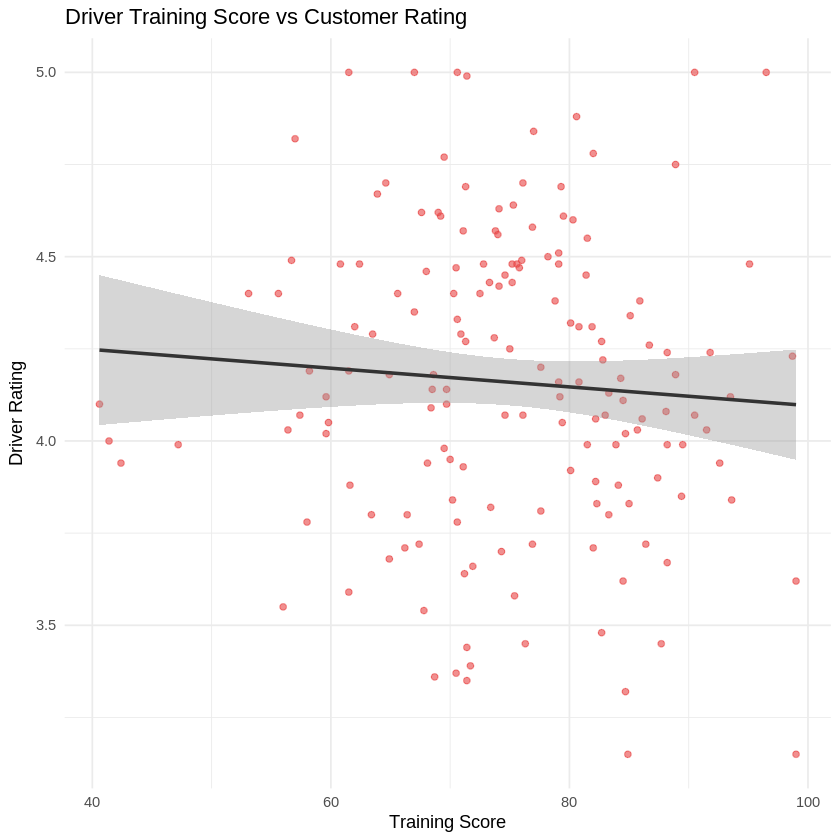

In [ ]:
ggplot(drivers, aes(x = training_score, y = driver_rating)) +
  geom_point(color = "#e84545", alpha = 0.6) +
  geom_smooth(method = "lm", se = TRUE, color = "#333333") +
  labs(
    title = "Driver Training Score vs Customer Rating",
    x     = "Training Score",
    y     = "Driver Rating"
  ) +
  theme_minimal()

In [ ]:
# Print the correlation coefficient

cor_val <- cor(drivers$training_score, drivers$driver_rating, use = "complete.obs")
cat("\nCorrelation between training score and driver rating:", round(cor_val, 3), "\n")


Correlation between training score and driver rating: -0.07 


**6th Analysis: Vehicle Battery Health by Maintenance Status**

Vehicles in repair or scheduled maintenance should have lower battery health. This checks if the maintenance system is correctly identifying at-risk vehicles.

In [ ]:
vehicles_clean <- vehicles %>%
  filter(!is.na(battery_health_pct))

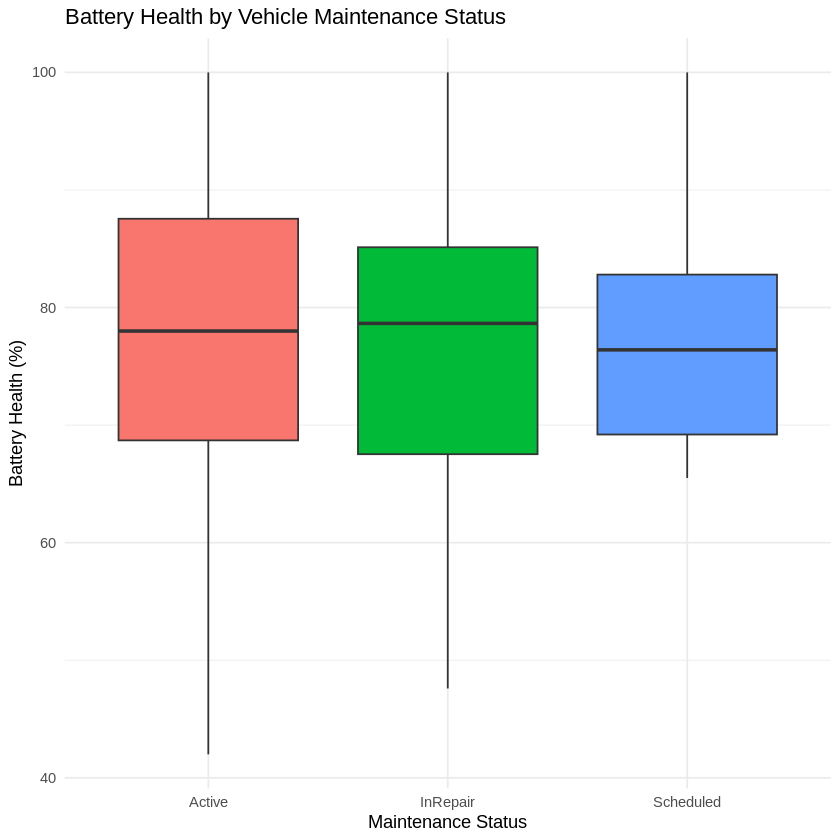

In [ ]:
ggplot(vehicles_clean, aes(x = maintenance_status, y = battery_health_pct, fill = maintenance_status)) +
  geom_boxplot() +
  labs(
    title = "Battery Health by Vehicle Maintenance Status",
    x     = "Maintenance Status",
    y     = "Battery Health (%)"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

**7th Analysis: Complaint Frequency by Customer Type**

Are Enterprise customers complaining more than Consumer customers? This helps understand where service gaps are most damaging to the business relationship.

In [ ]:
complaints_joined <- complaints %>%
  left_join(customers, by = "customer_id")

complaint_by_type <- complaints_joined %>%
  group_by(customer_type) %>%
  summarise(total_complaints = n(),
            avg_compensation  = round(mean(compensation_amount, na.rm = TRUE), 2))

cat("\n Complaints by Customer Type \n")
print(complaint_by_type)


 Complaints by Customer Type 
# A tibble: 3 × 3
  customer_type total_complaints avg_compensation
  <chr>                    <int>            <dbl>
1 Consumer                   242             20.6
2 Enterprise                  28             20.2
3 SME                         50             18.5


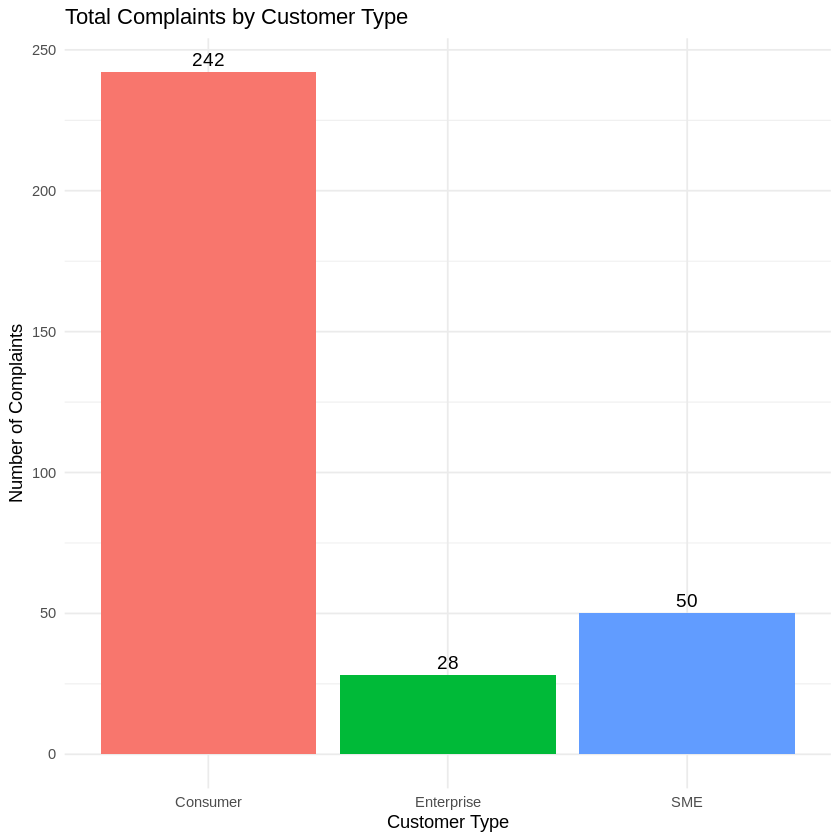

In [ ]:
ggplot(complaint_by_type, aes(x = customer_type, y = total_complaints, fill = customer_type)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = total_complaints), vjust = -0.5, size = 4) +
  labs(
    title = "Total Complaints by Customer Type",
    x     = "Customer Type",
    y     = "Number of Complaints"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

**8th Analysis: Fuel/Charge Cost vs Route Distance**

There should be a positive relationship between how far a vehicle travels and how much fuel or charge it uses. Outliers may indicate inefficient routes or vehicle faults.

`geom_smooth()` using formula = 'y ~ x'


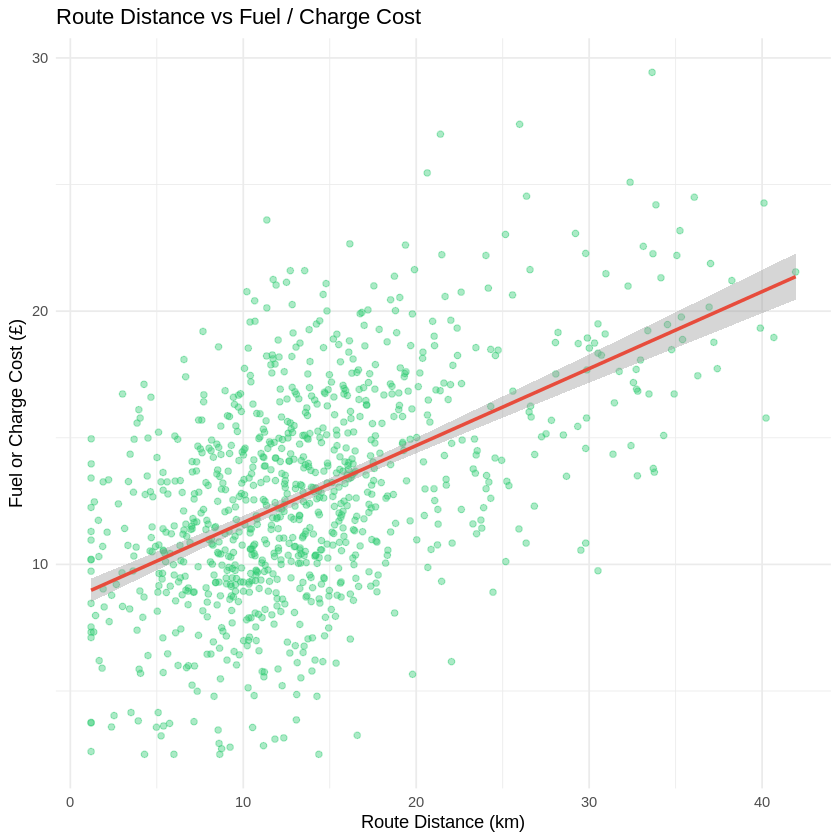

In [ ]:
ggplot(deliveries, aes(x = route_distance_km, y = fuel_or_charge_cost)) +
  geom_point(alpha = 0.4, color = "#2ecc71") +
  geom_smooth(method = "lm", se = TRUE, color = "#e74c3c") +
  labs(
    title = "Route Distance vs Fuel / Charge Cost",
    x     = "Route Distance (km)",
    y     = "Fuel or Charge Cost (£)"
  ) +
  theme_minimal()

In [ ]:
cor_cost <- cor(deliveries$route_distance_km, deliveries$fuel_or_charge_cost, use = "complete.obs")
cat("\nCorrelation between route distance and cost:", round(cor_cost, 3), "\n")


Correlation between route distance and cost: 0.524 


**9th Analysis: Incident Types Breakdown**

Understanding which incident types occur most frequently helps management prioritise where to focus operational improvements and safety investments.

In [ ]:
incident_summary <- incidents %>%
  group_by(incident_type) %>%
  summarise(
    count            = n(),
    avg_resolved_hrs = round(mean(resolved_hours, na.rm = TRUE), 2)
  ) %>%
  arrange(desc(count))

cat("\n Incident Type Summary \n")
print(incident_summary)



 Incident Type Summary 
# A tibble: 8 × 3
  incident_type    count avg_resolved_hrs
  <chr>            <int>            <dbl>
1 ProofMissing        46            10.8 
2 CustomerNoShow      44            13.9 
3 RouteDeviation      43            13.7 
4 VehicleFault        37             9.15
5 BatteryAlert        36            11.7 
6 AppSyncError        31            12.7 
7 TemperatureIssue    29            12.9 
8 SafetyNearMiss      14             9.67


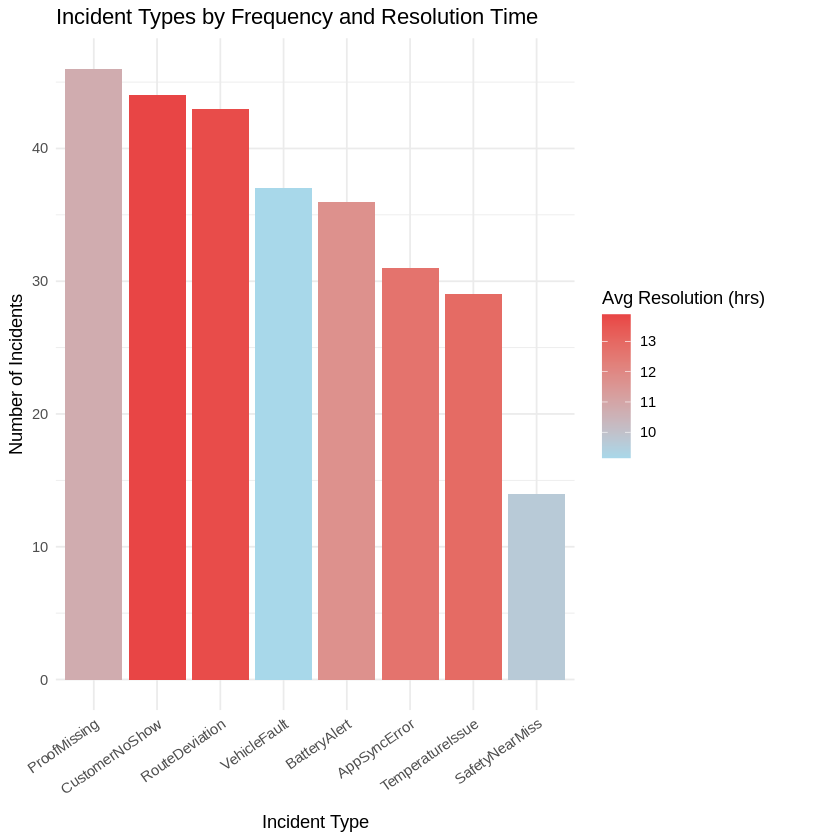

In [ ]:
ggplot(incident_summary, aes(x = reorder(incident_type, -count), y = count, fill = avg_resolved_hrs)) +
  geom_bar(stat = "identity") +
  scale_fill_gradient(low = "#a8d8ea", high = "#e84545") +
  labs(
    title = "Incident Types by Frequency and Resolution Time",
    x     = "Incident Type",
    y     = "Number of Incidents",
    fill  = "Avg Resolution (hrs)"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 35, hjust = 1))

**10th Analysis: Driver Experience vs Delivery Performance**

Do more experienced drivers have fewer failed deliveries? We join drivers with deliveries and compare failure rates across experience levels.

In [ ]:
driver_performance <- deliveries %>%
  left_join(drivers, by = "driver_id") %>%
  filter(!is.na(years_experience)) %>%
  mutate(is_failed = ifelse(delivery_status == "Failed", 1, 0)) %>%
  group_by(years_experience) %>%
  summarise(
    total     = n(),
    failures  = sum(is_failed),
    fail_rate = round(100 * failures / total, 1)
  )

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


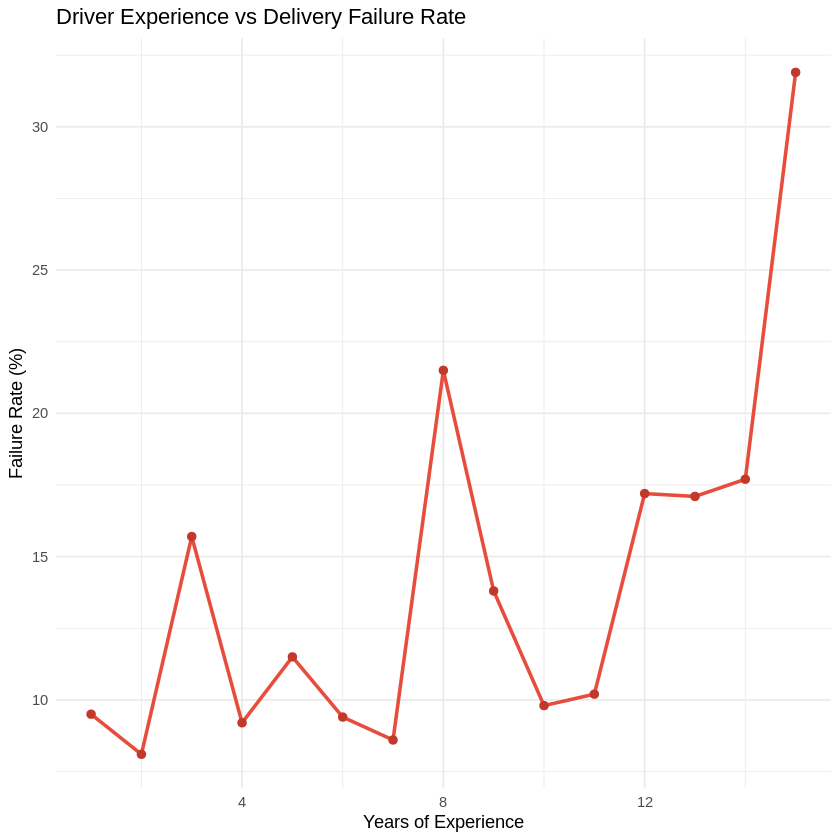

In [ ]:
ggplot(driver_performance, aes(x = years_experience, y = fail_rate)) +
  geom_line(color = "#e74c3c", size = 1) +
  geom_point(color = "#c0392b", size = 2) +
  labs(
    title = "Driver Experience vs Delivery Failure Rate",
    x     = "Years of Experience",
    y     = "Failure Rate (%)"
  ) +
  theme_minimal()